## CMPE-257, Machine Learning, Summer 2025
## Week 8: Support Vector Machines
In this workbook, you will be exploring SVM classification and regression paradigms
- Maximal Margins and Kernels
- Support Vector Classification
- Support Vector Regression

In [2]:
# YOUR NAME: QUOC DUNG LAM

In [3]:
# loads required modules
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits, load_diabetes
from sklearn.metrics import mean_squared_error, classification_report, confusion_matrix, PredictionErrorDisplay
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.manifold import TSNE
from sklearn.svm import SVC, SVR

## PART 1: Maximal Margins and Kernels

In [4]:
# Loads the digits dataset and displays its description

digits = load_digits()
print(digits.DESCR)

.. _digits_dataset:

Optical recognition of handwritten digits dataset
--------------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 1797
:Number of Attributes: 64
:Attribute Information: 8x8 image of integer pixels in the range 0..16.
:Missing Attribute Values: None
:Creator: E. Alpaydin (alpaydin '@' boun.edu.tr)
:Date: July; 1998

This is a copy of the test set of the UCI ML hand-written digits datasets
https://archive.ics.uci.edu/ml/datasets/Optical+Recognition+of+Handwritten+Digits

The data set contains images of hand-written digits: 10 classes where
each class refers to a digit.

Preprocessing programs made available by NIST were used to extract
normalized bitmaps of handwritten digits from a preprinted form. From a
total of 43 people, 30 contributed to the training set and different 13
to the test set. 32x32 bitmaps are divided into nonoverlapping blocks of
4x4 and the number of on pixels are counted in each block. This generates
an in

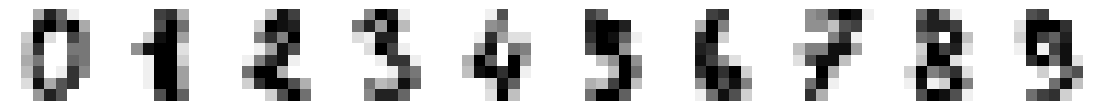

In [5]:
# Dispalys the first ten data samples

fig, ax = plt.subplots(1,10,figsize=(14,6))
for k in range(10):
    ax[k].imshow(1-digits.images[k], cmap="gray")
    ax[k].set_axis_off()
plt.show()

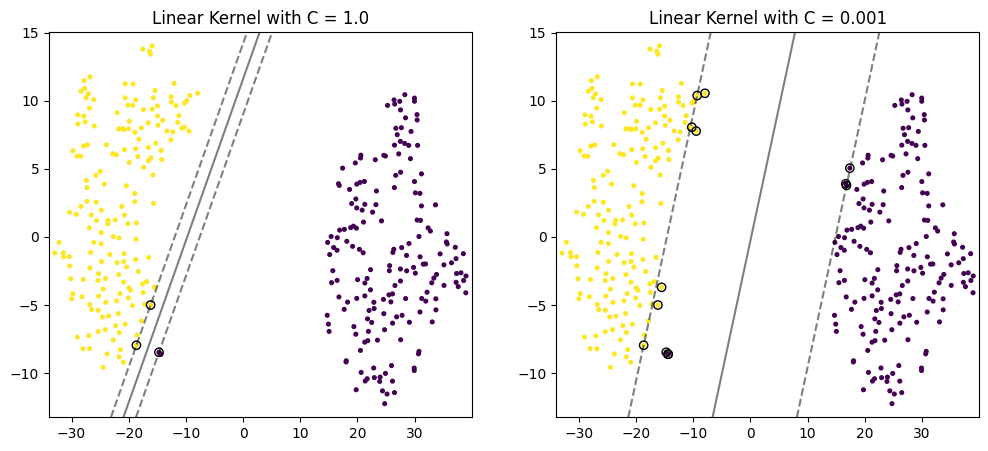

In [6]:
# Exercise #1: consider the two linearly separable classes "4" and "8", for which we project the feature
# space into a two-dimensional space by using TSNE(). A linear kernel is used to learn a maximum margin
# classifier using two values of the C parameter: C = 1.0 and C = 0.001

da = 8
db = 4
cvals = [1.0,0.001]

# gets the data corresponding to the two classes of interest and projects the features in 2 dimensions
idx = (digits.target==da) | (digits.target==db)
two_digits_feat = digits.data[idx,:]
two_digits_tgt = digits.target[idx]
two_digits_low = TSNE(n_components=2,random_state=1).fit_transform(two_digits_feat)

# learns and plots the separating hyperplane and margins, along with data points and support vectors, for 
# two different parameter setups: C = 1.0 and C = 0.001
fig, ax = plt.subplots(1,2,figsize=(12,5))
for k in range(2):
    svm = SVC(C=cvals[k], kernel='linear', random_state=1)
    svm.fit(two_digits_low,two_digits_tgt)
    scatter = ax[k].scatter(two_digits_low[:,0], two_digits_low[:,1], s=7, c=two_digits_tgt, label=two_digits_tgt)
    ax[k].scatter(svm.support_vectors_[:,0], svm.support_vectors_[:,1], c='none', label='Support Vectors', edgecolors="k")
    ax[k].set_title('Linear Kernel with C = '+str(cvals[k]))
    DecisionBoundaryDisplay.from_estimator(svm, two_digits_low, plot_method="contour", colors="k", levels=[-1, 0, 1],
                                           alpha=0.5, linestyles=["--", "-", "--"], ax=ax[k])
plt.show()

In [7]:
# What are your main observations from exercise #1?
# For larger C, the margin is narrower. The model tries to correctly classify all.
# For lower C, the margin is much wider, there're more support vectors too.

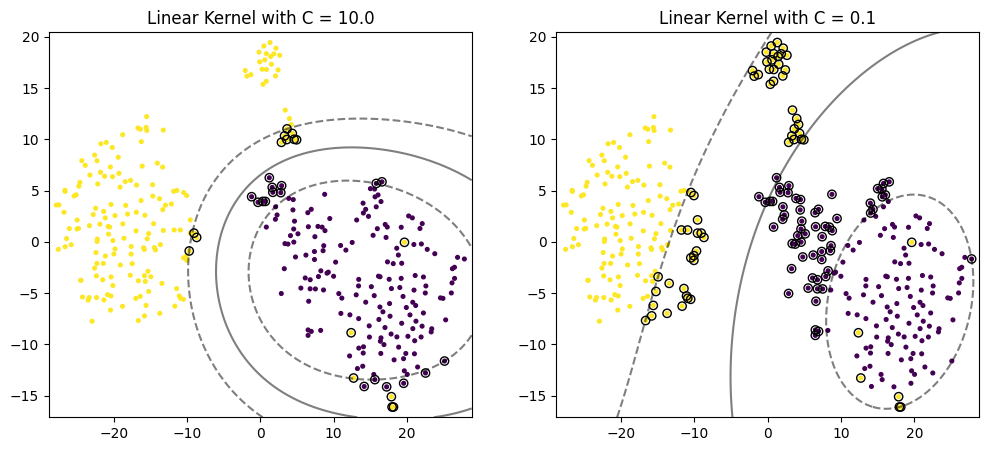

In [8]:
# Exercise #2: consider the two non-linearly separable classes "8" and "9" and, reuse the code in exercise #1, 
# to project the feature space into a two-dimensional space by using TSNE(). This time use an RBF kernel to 
# learn a maximum margin classifier using C = 10.0 and C = 0.1 (use a value of gamma = 0.001 in both cases). 
# Again, reuse the code in exercise #1, to generate the corresponding plots

da = 9
db = 8
cvals = [10.0,0.1]
gamma = 0.001

# gets the data corresponding to the two classes of interest and projects the features in 2 dimensions
idx = (digits.target==da) | (digits.target==db)
two_digits_feat = digits.data[idx,:]
two_digits_tgt = digits.target[idx]
two_digits_low = TSNE(n_components=2,random_state=1).fit_transform(two_digits_feat)

# learns and plots the separating hyperplane and margins, along with data points and support vectors, for 
# two different parameter setups: C = 1.0 and C = 0.001
fig, ax = plt.subplots(1,2,figsize=(12,5))
for k in range(2):
    svm = SVC(C=cvals[k], kernel='rbf', random_state=1, gamma=gamma)
    svm.fit(two_digits_low,two_digits_tgt)
    scatter = ax[k].scatter(two_digits_low[:,0], two_digits_low[:,1], s=7, c=two_digits_tgt, label=two_digits_tgt)
    ax[k].scatter(svm.support_vectors_[:,0], svm.support_vectors_[:,1], c='none', label='Support Vectors', edgecolors="k")
    ax[k].set_title('Linear Kernel with C = '+str(cvals[k]))
    DecisionBoundaryDisplay.from_estimator(svm, two_digits_low, plot_method="contour", colors="k", levels=[-1, 0, 1],
                                           alpha=0.5, linestyles=["--", "-", "--"], ax=ax[k])
plt.show()


In [9]:
# What are your main observations from exercise #2? How these results compare from those from exercise #1?
# For C = 10, the model tries to classify all the data points correctly. The decision boundary is tight and curve. The model is complex 
# and at risk of overfitting.
# For C = 0.1, the decision boundary is smoother and almost linear. Since the margin is wider, more points become the support vector.
# The model is too simple and at risk of underfitting
# Compare to the exercise 1, RBF is smoother and highly curve, and has more flexibility.

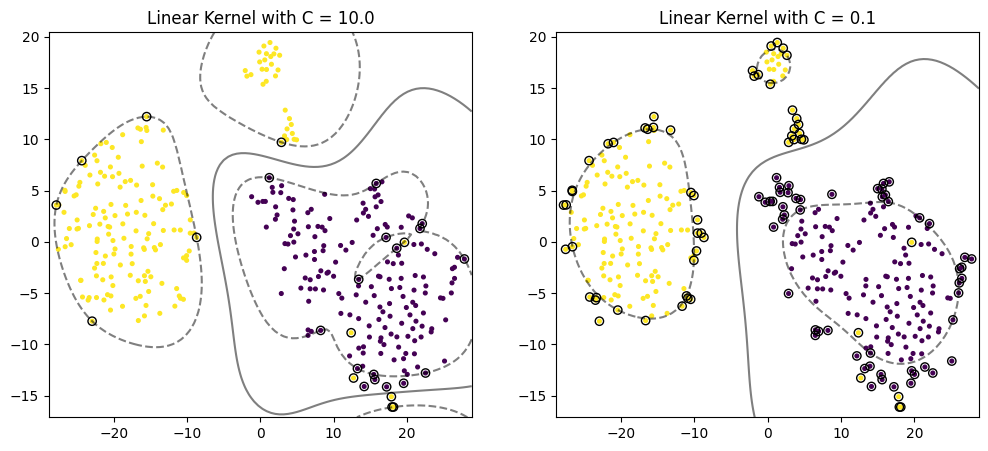

In [10]:
# Exercise #3: repeat exercise #2 but use a value of gamma = 0.01 in both cases this time

da = 9
db = 8
cvals = [10.0,0.1]
gamma = 0.01

# gets the data corresponding to the two classes of interest and projects the features in 2 dimensions
idx = (digits.target==da) | (digits.target==db)
two_digits_feat = digits.data[idx,:]
two_digits_tgt = digits.target[idx]
two_digits_low = TSNE(n_components=2,random_state=1).fit_transform(two_digits_feat)

# learns and plots the separating hyperplane and margins, along with data points and support vectors, for 
# two different parameter setups: C = 1.0 and C = 0.001
fig, ax = plt.subplots(1,2,figsize=(12,5))
for k in range(2):
    svm = SVC(C=cvals[k], kernel='rbf', random_state=1, gamma=gamma)
    svm.fit(two_digits_low,two_digits_tgt)
    scatter = ax[k].scatter(two_digits_low[:,0], two_digits_low[:,1], s=7, c=two_digits_tgt, label=two_digits_tgt)
    ax[k].scatter(svm.support_vectors_[:,0], svm.support_vectors_[:,1], c='none', label='Support Vectors', edgecolors="k")
    ax[k].set_title('Linear Kernel with C = '+str(cvals[k]))
    DecisionBoundaryDisplay.from_estimator(svm, two_digits_low, plot_method="contour", colors="k", levels=[-1, 0, 1],
                                           alpha=0.5, linestyles=["--", "-", "--"], ax=ax[k])
plt.show()



In [11]:
# What are your main observations from exercise #3? How these results compare from those from exercise #2?
# For C = 10, the model has stricter classification, and has narrower margin.
# For C = 0.1, the model has wider margin, yet more overlap cluster between 8 and 9
# This show the effect of gamma, with gamma 0.01, the model are much smoother, and produces a simpler model. 
# Lowering gamma reduces the complexity, regardless of C.

## PART 2: Support Vector Classification

In [12]:
# Exercise #4: use GridSearchCV() to conduct parameter fine-tuning with cross-validation, use KFold() to
# set up a cross-validation experiment with n_splits = 5. Consider the provided data split and parameter 
# grid for your experiment. Display the obtained optimal values for 'C', 'degree', 'gamma' and 'kernel'.
# Use also random_state = 1

trn_feat, tst_feat, trn_tgt, tst_tgt = train_test_split(digits.data, digits.target, test_size=0.5, random_state=1)
svm_param = {'C':[0.001,0.005,0.01,0.05,0.1,5.0,10.0],
             'degree':[3,4,5,6],
             'gamma':[0.0001,0.001,0.01,0.1],
             'kernel':['linear','poly','rbf']}

cv = KFold(n_splits=5, shuffle=True, random_state=1)

grid = GridSearchCV(estimator=SVC(random_state=1), cv=cv, param_grid=svm_param, scoring='accuracy')
grid.fit(trn_feat, trn_tgt)

print(f'Best Params = {grid.best_params_}')
print(f'Best Score = {grid.best_score_}')


Best Params = {'C': 5.0, 'degree': 3, 'gamma': 0.001, 'kernel': 'rbf'}
Best Score = 0.9933209186840471


In [13]:
# What are your main observations from exercise #4?
# The higher the score, the more complex model needed.

In [14]:
# Exercise #5: consider the optimal parameter set obtained in exercise #4, use SVC() and the train dataset
# from the previous exercise to learn a Support Vector Machine classifier. Evaluate the classifier perfomance
# over both the train and test datasets using classification_report() and display the corresponding results

# Use the optimal parameters found from GridSearchCV
svc = SVC(C=5.0, gamma=0.001, kernel='rbf', random_state=1)
svc.fit(trn_feat, trn_tgt)

# Evaluate on Training Set
train_pred = svc.predict(trn_feat)
train_report = classification_report(trn_tgt, train_pred, output_dict=True)
train_df = pd.DataFrame(train_report).transpose()
print("Training Set Performance:")
print(train_df.round(3))

# Evaluate on Testing Set
test_pred = svc.predict(tst_feat)
test_report = classification_report(tst_tgt, test_pred, output_dict=True)
test_df = pd.DataFrame(test_report).transpose()
print("\nTesting Set Performance:")
print(test_df.round(3))

Training Set Performance:
              precision  recall  f1-score  support
0                   1.0     1.0       1.0     95.0
1                   1.0     1.0       1.0     89.0
2                   1.0     1.0       1.0     92.0
3                   1.0     1.0       1.0     85.0
4                   1.0     1.0       1.0     81.0
5                   1.0     1.0       1.0    101.0
6                   1.0     1.0       1.0     93.0
7                   1.0     1.0       1.0     90.0
8                   1.0     1.0       1.0     93.0
9                   1.0     1.0       1.0     79.0
accuracy            1.0     1.0       1.0      1.0
macro avg           1.0     1.0       1.0    898.0
weighted avg        1.0     1.0       1.0    898.0

Testing Set Performance:
              precision  recall  f1-score  support
0                 1.000   1.000     1.000   83.000
1                 1.000   0.989     0.995   93.000
2                 1.000   1.000     1.000   85.000
3                 1.000   0.99

In [ ]:
# What are your main observations from exercise #5?
# The result model has a high accuracy for both training set and testing set. 
# No sign of overfitting
# Generailize well to unseen data with 98.9% on test set

Confusion Matrix:
[[ 83   0   0   0   0   0   0   0   0   0]
 [  0  92   0   0   0   0   0   0   1   0]
 [  0   0  85   0   0   0   0   0   0   0]
 [  0   0   0  97   0   0   0   1   0   0]
 [  0   0   0   0 100   0   0   0   0   0]
 [  0   0   0   0   0  79   1   0   0   1]
 [  0   0   0   0   0   0  88   0   0   0]
 [  0   0   0   0   0   0   0  88   0   1]
 [  0   0   0   0   0   0   0   0  81   0]
 [  0   0   0   0   0   3   0   0   2  96]]


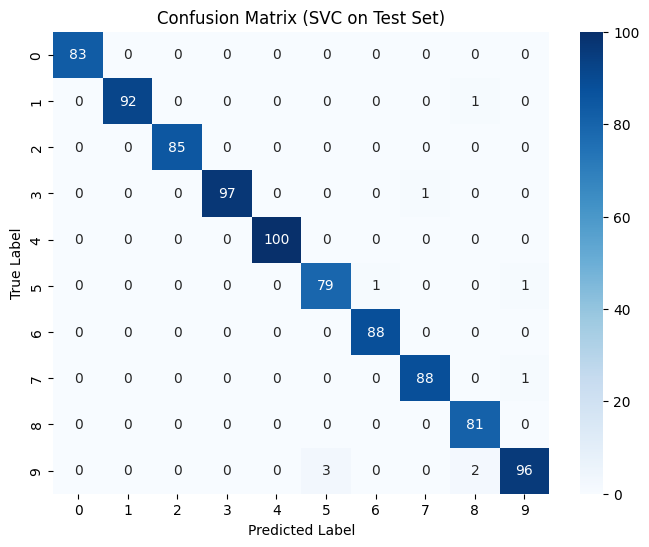

In [19]:
# Exercise #6: use confusion_matrix() to compute the confusion matrix for the test dataset from exercise #5

cm = confusion_matrix(tst_tgt, test_pred)
print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (SVC on Test Set)')
plt.show()

In [ ]:
# What are your main observations from exercise #6?
# No major confusion spotted.
# This result support the achievement we got from #6
# Class 9 has the most spread out, 3 predicted to 5, and 2 to 8

## PART 3: Support Vector Regression

In [19]:
# Loads the diabetes dataset and displays its description 

diabetes = load_diabetes()
print(diabetes.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [20]:
# Exercise #7: create cross-plots (in a 2x5 plot grid) between each of the 10 predictor variable and 
# the target variable "quantitative measure of disease progression one year after baseline"

# add your code here...


In [21]:
# What are your main observations from exercise #7?
# <write your comments here>

In [22]:
# Exercise #8: use SVR() to train three linear regression models using feature 8 as the single predictor 
# variable (use all available data points). Consider the same value of C = 1000 in all three cases, while 
# varying the value of epsilon: 50, 100, 200. Create a plot for each generated rgeression line L, along with 
# the two auxiliary lines L+epsilon and L-epsilon. Include the data points in the plots too and compute and 
# display the resulting MSEs in each case

# add your code here...


In [23]:
# What are your main observations from exercise #8?
# <write your comments here>

In [24]:
# Exercise #9: use GridSearchCV() to conduct parameter fine-tuning with cross-validation, use KFold() to
# set up a cross-validation experiment with n_splits = 50. Consider the provided data split and parameter 
# grid for your experiment. Display the obtained optimal values for 'C', 'gamma' and 'kernel'. Use also
# random_state = 1

trn_feat, tst_feat, trn_tgt, tst_tgt = train_test_split(diabetes.data, diabetes.target, test_size=0.5, random_state=1)
svr_param = {'C':[1.0,10.0,100.0,1000.0,10000.0],
             'gamma':[0.01,0.1,1.0,10.0,100.0],
             'kernel':['rbf','linear']}

# add your code here...


In [25]:
# What are your main observations from exercise #9?
# <write your comments here>

In [26]:
# Exercise #10: use the optimal parameters obtained in exercise #9 and train a new model, using all the
# data points available this time. Compute the predictions produced by the new model and estimate the MSE

# add your code here...


In [27]:
# What are your main observations from exercise #10? How these results compare to those from exercise #8?
# <write your comments here>